# Tabular full baseline

In [8]:
from pathlib import Path
import json
import sys
import pandas as pd

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from tabular_baseline_utils import (
    prepare_dataframes,
    build_preprocessor,
    build_logreg_pipeline,
    fit_model,
    evaluate_model,
    search_thresholds,
    compute_cost_table,
    evaluate_with_threshold,
    compute_expected_cost_from_cm,
    save_experiment_outputs,
)

project_root = Path.cwd().parent
processed_dir = project_root / "data" / "processed"
results_root = project_root / "results"

print("Project root:", project_root)
print("Processed dir:", processed_dir)
print("Results root:", results_root)

Project root: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis
Processed dir: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed
Results root: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results


# Tabular full baseline



In [9]:
paysim_train = pd.read_csv(processed_dir / "paysim_train.csv")
paysim_val = pd.read_csv(processed_dir / "paysim_val.csv")
paysim_test = pd.read_csv(processed_dir / "paysim_test.csv")

data = prepare_dataframes(paysim_train, paysim_val, paysim_test)

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

categorical_features = data["categorical_features"]
numeric_features = data["numeric_features"]
feature_cols = data["feature_cols"]

print("Features used:", feature_cols)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("\nTrain class counts:")
print(y_train.value_counts())

Features used: ['type', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']
X_train shape: (4453834, 8)
X_val shape: (636262, 8)
X_test shape: (1272524, 8)

Train class counts:
isFraud
0    4448085
1       5749
Name: count, dtype: int64


In [10]:
preprocessor = build_preprocessor(numeric_features, categorical_features)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['step', 'amount', 'oldbalanceOrg',
                                  'newbalanceOrig', 'oldbalanceDest',
                                  'newbalanceDest', 'isFlaggedFraud']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['type'])])

## 1. Logistic Regression without imbalance handling

This version uses the original PaySim split and trains Logistic Regression without any balancing method.

In [11]:
results_dir = results_root / "tabular_full_baseline_none"
results_dir.mkdir(parents=True, exist_ok=True)

model_none = build_logreg_pipeline(
    preprocessor=preprocessor,
    imbalance_method="none",
)

model_none = fit_model(model_none, X_train, y_train)
print("Training finished.")

Training finished.


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [12]:
val_metrics_none, val_cm_none = evaluate_model(model_none, X_val, y_val, split_name="validation_none")
test_metrics_none, test_cm_none = evaluate_model(model_none, X_test, y_test, split_name="test_none")



=== VALIDATION_NONE ===
accuracy: 0.998982
precision: 0.994286
recall: 0.211937
f1: 0.349398
roc_auc: 0.946992
pr_auc: 0.449465

Confusion matrix:
[[635440      1]
 [   647    174]]

Classification report:
              precision    recall  f1-score   support

           0     0.9990    1.0000    0.9995    635441
           1     0.9943    0.2119    0.3494       821

    accuracy                         0.9990    636262
   macro avg     0.9966    0.6060    0.6744    636262
weighted avg     0.9990    0.9990    0.9987    636262


=== TEST_NONE ===
accuracy: 0.998988
precision: 0.997199
recall: 0.216677
f1: 0.356000
roc_auc: 0.952047
pr_auc: 0.454219

Confusion matrix:
[[1270880       1]
 [   1287     356]]

Classification report:
              precision    recall  f1-score   support

           0     0.9990    1.0000    0.9995   1270881
           1     0.9972    0.2167    0.3560      1643

    accuracy                         0.9990   1272524
   macro avg     0.9981    0.6083    0.6777

In [13]:
threshold_results_none = search_thresholds(model_none, X_val, y_val)
threshold_results_none

,threshold,precision,recall,f1,predicted_fraud
0,0.10,0.931034,0.328867,0.486049,290
1,0.15,0.976096,0.298417,0.457090,251
2,0.20,0.987179,0.281364,0.437915,234
3,0.25,0.990868,0.264312,0.417308,219
4,0.30,0.990244,0.247259,0.395712,205
5,0.35,0.994872,0.236297,0.381890,195
6,0.40,0.994737,0.230207,0.373887,190
7,0.45,0.994536,0.221681,0.362550,183
8,0.50,0.994286,0.211937,0.349398,175
9,0.55,0.994186,0.208283,0.344411,172


In [14]:
cost_df_none = compute_cost_table(threshold_results_none, y_val)
cost_df_none.head()

,threshold,tp,fp,fn,tn,precision,recall,f1,predicted_fraud,expected_cost
0,0.10,270,20,551,635421,0.931034,0.328867,0.486049,290,27560000
1,0.15,245,6,576,635435,0.976096,0.298417,0.457090,251,28803000
2,0.20,231,3,590,635438,0.987179,0.281364,0.437915,234,29501500
3,0.25,217,2,604,635439,0.990868,0.264312,0.417308,219,30201000
4,0.30,203,2,618,635439,0.990244,0.247259,0.395712,205,30901000


In [15]:
best_threshold_none = float(cost_df_none.iloc[0]["threshold"])
best_threshold_none

0.1

In [16]:
tuned_metrics_none, tuned_cm_none = evaluate_with_threshold(model_none, X_test, y_test, best_threshold_none)
cost_summary_none = compute_expected_cost_from_cm(tuned_cm_none)

print(cost_summary_none)


Tuned threshold: 0.1
Precision: 0.956140350877193
Recall: 0.3317102860620816
F1: 0.49254405784003613

Confusion matrix:
[[1270856      25]
 [   1098     545]]

Classification report:
              precision    recall  f1-score   support

           0     0.9991    1.0000    0.9996   1270881
           1     0.9561    0.3317    0.4925      1643

    accuracy                         0.9991   1272524
   macro avg     0.9776    0.6658    0.7461   1272524
weighted avg     0.9991    0.9991    0.9989   1272524

{'tp': 545, 'fp': 25, 'fn': 1098, 'tn': 1270856, 'expected_cost': 54912500}


In [17]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_none,
    val_metrics=val_metrics_none,
    test_metrics=test_metrics_none,
    val_cm=val_cm_none,
    test_cm=test_cm_none,
    threshold_results=threshold_results_none,
    cost_df=cost_df_none,
    tuned_metrics=tuned_metrics_none,
    tuned_cm=tuned_cm_none,
    prefix="none",
)

print("Saved outputs to:", results_dir)

Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_baseline_none


In [18]:
from pathlib import Path

saved_files = sorted([p.name for p in Path(results_dir).glob("*")])
saved_files

['none_cost_results.csv',
 'none_metrics_summary.csv',
 'none_model.joblib',
 'none_test_confusion_matrix.csv',
 'none_test_metrics.json',
 'none_threshold_results.csv',
 'none_tuned_test_confusion_matrix.csv',
 'none_tuned_test_metrics.json',
 'none_validation_confusion_matrix.csv',
 'none_validation_metrics.json']

In [ ]:
#For retriting the trainde results after restarting the kernal without training the model agam scratch
import joblib

model_none = joblib.load(results_dir / "none_model.joblib")
print("Loaded saved model.")

## 2. Logistic Regression with class weights

This version uses the same features and split, but applies `class_weight="balanced"` during training.

In [19]:
results_dir = results_root / "tabular_full_baseline_class_weight"
results_dir.mkdir(parents=True, exist_ok=True)

print("Results dir:", results_dir)

Results dir: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_baseline_class_weight


In [20]:
preprocessor = build_preprocessor(numeric_features, categorical_features)

model_weighted = build_logreg_pipeline(
    preprocessor=preprocessor,
    imbalance_method="class_weight",
)

model_weighted = fit_model(model_weighted, X_train, y_train)
print("Training finished.")

Training finished.


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [21]:
val_metrics_weighted, val_cm_weighted = evaluate_model(
    model_weighted, X_val, y_val, split_name="validation_class_weight"
)

test_metrics_weighted, test_cm_weighted = evaluate_model(
    model_weighted, X_test, y_test, split_name="test_class_weight"
)


=== VALIDATION_CLASS_WEIGHT ===
accuracy: 0.949467
precision: 0.023888
recall: 0.957369
f1: 0.046614
roc_auc: 0.991780
pr_auc: 0.599905

Confusion matrix:
[[603324  32117]
 [    35    786]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9495    0.9740    635441
           1     0.0239    0.9574    0.0466       821

    accuracy                         0.9495    636262
   macro avg     0.5119    0.9534    0.5103    636262
weighted avg     0.9987    0.9495    0.9728    636262


=== TEST_CLASS_WEIGHT ===
accuracy: 0.949581
precision: 0.024188
recall: 0.967133
f1: 0.047195
roc_auc: 0.992945
pr_auc: 0.601748

Confusion matrix:
[[1206775   64106]
 [     54    1589]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9496    0.9741   1270881
           1     0.0242    0.9671    0.0472      1643

    accuracy                         0.9496   1272524
   macro avg     0.5121    

In [22]:
threshold_results_weighted = search_thresholds(model_weighted, X_val, y_val)
threshold_results_weighted.head()

,threshold,precision,recall,f1,predicted_fraud
0,0.10,0.004923,1.000000,0.009798,166762
1,0.15,0.005787,1.000000,0.011507,141875
2,0.20,0.006797,1.000000,0.013503,120784
3,0.25,0.008034,1.000000,0.015941,102187
4,0.30,0.009624,0.997564,0.019063,85103


In [23]:
cost_df_weighted = compute_cost_table(threshold_results_weighted, y_val)
cost_df_weighted.head()

,threshold,tp,fp,fn,tn,precision,recall,f1,predicted_fraud,expected_cost
0,0.75,681,7852,140,627589,0.079808,0.829476,0.145606,8533,10926000
1,0.70,707,10910,114,624531,0.060859,0.861145,0.113684,11617,11155000
2,0.80,647,5309,174,630132,0.108630,0.788063,0.190940,5956,11354500
3,0.65,730,14451,91,620990,0.048086,0.889160,0.091239,15181,11775500
4,0.85,616,3130,205,632311,0.164442,0.750305,0.269761,3746,11815000


In [24]:
best_threshold_weighted = float(cost_df_weighted.iloc[0]["threshold"])
best_threshold_weighted

0.7500000000000002

In [25]:
tuned_metrics_weighted, tuned_cm_weighted = evaluate_with_threshold(
    model_weighted, X_test, y_test, best_threshold_weighted
)

cost_summary_weighted = compute_expected_cost_from_cm(tuned_cm_weighted)
print(cost_summary_weighted)


Tuned threshold: 0.7500000000000002
Precision: 0.08368719037508847
Recall: 0.8636640292148509
F1: 0.15258884886284207

Confusion matrix:
[[1255344   15537]
 [    224    1419]]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9878    0.9938   1270881
           1     0.0837    0.8637    0.1526      1643

    accuracy                         0.9876   1272524
   macro avg     0.5418    0.9257    0.5732   1272524
weighted avg     0.9986    0.9876    0.9927   1272524

{'tp': 1419, 'fp': 15537, 'fn': 224, 'tn': 1255344, 'expected_cost': 18968500}


In [26]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_weighted,
    val_metrics=val_metrics_weighted,
    test_metrics=test_metrics_weighted,
    val_cm=val_cm_weighted,
    test_cm=test_cm_weighted,
    threshold_results=threshold_results_weighted,
    cost_df=cost_df_weighted,
    tuned_metrics=tuned_metrics_weighted,
    tuned_cm=tuned_cm_weighted,
    prefix="class_weight",
)

print("Saved outputs to:", results_dir)

Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_baseline_class_weight


In [27]:
from pathlib import Path

saved_files = sorted([p.name for p in Path(results_dir).glob("*")])
saved_files

['class_weight_cost_results.csv',
 'class_weight_metrics_summary.csv',
 'class_weight_model.joblib',
 'class_weight_test_confusion_matrix.csv',
 'class_weight_test_metrics.json',
 'class_weight_threshold_results.csv',
 'class_weight_tuned_test_confusion_matrix.csv',
 'class_weight_tuned_test_metrics.json',
 'class_weight_validation_confusion_matrix.csv',
 'class_weight_validation_metrics.json']

## 3. Logistic Regression with SMOTE

This version uses the same features and split, but applies SMOTE only on the training data.

In [28]:
results_dir = results_root / "tabular_full_baseline_smote"
results_dir.mkdir(parents=True, exist_ok=True)

print("Results dir:", results_dir)

Results dir: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_baseline_smote


In [29]:
preprocessor = build_preprocessor(numeric_features, categorical_features)

model_smote = build_logreg_pipeline(
    preprocessor=preprocessor,
    imbalance_method="smote",
)

model_smote = fit_model(model_smote, X_train, y_train)
print("Training finished.")

Training finished.


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [30]:
val_metrics_smote, val_cm_smote = evaluate_model(
    model_smote, X_val, y_val, split_name="validation_smote"
)

test_metrics_smote, test_cm_smote = evaluate_model(
    model_smote, X_test, y_test, split_name="test_smote"
)


=== VALIDATION_SMOTE ===
accuracy: 0.950871
precision: 0.024733
recall: 0.964677
f1: 0.048229
roc_auc: 0.993306
pr_auc: 0.619049

Confusion matrix:
[[604211  31230]
 [    29    792]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9509    0.9748    635441
           1     0.0247    0.9647    0.0482       821

    accuracy                         0.9509    636262
   macro avg     0.5123    0.9578    0.5115    636262
weighted avg     0.9987    0.9509    0.9736    636262


=== TEST_SMOTE ===
accuracy: 0.951280
precision: 0.025115
recall: 0.971394
f1: 0.048965
roc_auc: 0.994149
pr_auc: 0.619863

Confusion matrix:
[[1208930   61951]
 [     47    1596]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9513    0.9750   1270881
           1     0.0251    0.9714    0.0490      1643

    accuracy                         0.9513   1272524
   macro avg     0.5125    0.9613    0.51

In [31]:
threshold_results_smote = search_thresholds(model_smote, X_val, y_val)
threshold_results_smote.head()

,threshold,precision,recall,f1,predicted_fraud
0,0.10,0.006164,1.000000,0.012253,133190
1,0.15,0.007244,1.000000,0.014385,113328
2,0.20,0.008436,1.000000,0.016731,97323
3,0.25,0.009796,0.998782,0.019402,83705
4,0.30,0.011439,0.997564,0.022619,71595


In [32]:
cost_df_smote = compute_cost_table(threshold_results_smote, y_val)
cost_df_smote.head()

,threshold,tp,fp,fn,tn,precision,recall,f1,predicted_fraud,expected_cost
0,0.75,702,8619,119,626822,0.075314,0.855055,0.138434,9321,10259500
1,0.80,676,6027,145,629414,0.100850,0.823386,0.179692,6703,10263500
2,0.70,727,11488,94,623953,0.059517,0.885505,0.111537,12215,10444000
3,0.85,646,3810,175,631631,0.144973,0.786845,0.244836,4456,10655000
4,0.65,746,14877,75,620564,0.047750,0.908648,0.090732,15623,11188500


In [33]:
best_threshold_smote = float(cost_df_smote.iloc[0]["threshold"])
best_threshold_smote

0.7500000000000002

In [34]:
tuned_metrics_smote, tuned_cm_smote = evaluate_with_threshold(
    model_smote, X_test, y_test, best_threshold_smote
)

cost_summary_smote = compute_expected_cost_from_cm(tuned_cm_smote)
print(cost_summary_smote)


Tuned threshold: 0.7500000000000002
Precision: 0.07961122638418697
Recall: 0.887401095556908
F1: 0.14611414541263718

Confusion matrix:
[[1254025   16856]
 [    185    1458]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9867    0.9933   1270881
           1     0.0796    0.8874    0.1461      1643

    accuracy                         0.9866   1272524
   macro avg     0.5397    0.9371    0.5697   1272524
weighted avg     0.9987    0.9866    0.9922   1272524

{'tp': 1458, 'fp': 16856, 'fn': 185, 'tn': 1254025, 'expected_cost': 17678000}


In [35]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_smote,
    val_metrics=val_metrics_smote,
    test_metrics=test_metrics_smote,
    val_cm=val_cm_smote,
    test_cm=test_cm_smote,
    threshold_results=threshold_results_smote,
    cost_df=cost_df_smote,
    tuned_metrics=tuned_metrics_smote,
    tuned_cm=tuned_cm_smote,
    prefix="smote",
)

print("Saved outputs to:", results_dir)

Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_baseline_smote


In [36]:
from pathlib import Path

saved_files = sorted([p.name for p in Path(results_dir).glob("*")])
saved_files

['smote_cost_results.csv',
 'smote_metrics_summary.csv',
 'smote_model.joblib',
 'smote_test_confusion_matrix.csv',
 'smote_test_metrics.json',
 'smote_threshold_results.csv',
 'smote_tuned_test_confusion_matrix.csv',
 'smote_tuned_test_metrics.json',
 'smote_validation_confusion_matrix.csv',
 'smote_validation_metrics.json']

## 4. Comparison of imbalance-handling methods

The table below compares the results of the three Logistic Regression versions:
- no balancing
- class weights
- SMOTE

In [45]:
comparison_df = pd.DataFrame([
    {
        "model": "none",
        "val_f1": val_metrics_none["f1"],
        "val_roc_auc": val_metrics_none["roc_auc"],
        "val_pr_auc": val_metrics_none["pr_auc"],
        "test_f1": test_metrics_none["f1"],
        "test_roc_auc": test_metrics_none["roc_auc"],
        "test_pr_auc": test_metrics_none["pr_auc"],
        "best_threshold": best_threshold_none,
        "tuned_test_precision": tuned_metrics_none["precision"],
        "tuned_test_recall": tuned_metrics_none["recall"],
        "tuned_test_f1": tuned_metrics_none["f1"],
        "tuned_expected_cost": cost_summary_none["expected_cost"],
    },
    {
        "model": "class_weight",
        "val_f1": val_metrics_weighted["f1"],
        "val_roc_auc": val_metrics_weighted["roc_auc"],
        "val_pr_auc": val_metrics_weighted["pr_auc"],
        "test_f1": test_metrics_weighted["f1"],
        "test_roc_auc": test_metrics_weighted["roc_auc"],
        "test_pr_auc": test_metrics_weighted["pr_auc"],
        "best_threshold": best_threshold_weighted,
        "tuned_test_precision": tuned_metrics_weighted["precision"],
        "tuned_test_recall": tuned_metrics_weighted["recall"],
        "tuned_test_f1": tuned_metrics_weighted["f1"],
        "tuned_expected_cost": cost_summary_weighted["expected_cost"],
    },
    {
        "model": "smote",
        "val_f1": val_metrics_smote["f1"],
        "val_roc_auc": val_metrics_smote["roc_auc"],
        "val_pr_auc": val_metrics_smote["pr_auc"],
        "test_f1": test_metrics_smote["f1"],
        "test_roc_auc": test_metrics_smote["roc_auc"],
        "test_pr_auc": test_metrics_smote["pr_auc"],
        "best_threshold": best_threshold_smote,
        "tuned_test_precision": tuned_metrics_smote["precision"],
        "tuned_test_recall": tuned_metrics_smote["recall"],
        "tuned_test_f1": tuned_metrics_smote["f1"],
        "tuned_expected_cost": cost_summary_smote["expected_cost"],
    },
])

comparison_df

,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,none,0.349398,0.946992,0.449465,0.356000,0.952047,0.454219,0.10,0.956140,0.331710,0.492544,54912500
1,class_weight,0.046614,0.991780,0.599905,0.047195,0.992945,0.601748,0.75,0.083687,0.863664,0.152589,18968500
2,smote,0.048229,0.993306,0.619049,0.048965,0.994149,0.619863,0.75,0.079611,0.887401,0.146114,17678000


In [46]:
comparison_df.sort_values("tuned_expected_cost")


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
2,smote,0.048229,0.993306,0.619049,0.048965,0.994149,0.619863,0.75,0.079611,0.887401,0.146114,17678000
1,class_weight,0.046614,0.991780,0.599905,0.047195,0.992945,0.601748,0.75,0.083687,0.863664,0.152589,18968500
0,none,0.349398,0.946992,0.449465,0.356000,0.952047,0.454219,0.10,0.956140,0.331710,0.492544,54912500


In [47]:
comparison_df.sort_values("val_f1", ascending=False)


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,none,0.349398,0.946992,0.449465,0.356000,0.952047,0.454219,0.10,0.956140,0.331710,0.492544,54912500
2,smote,0.048229,0.993306,0.619049,0.048965,0.994149,0.619863,0.75,0.079611,0.887401,0.146114,17678000
1,class_weight,0.046614,0.991780,0.599905,0.047195,0.992945,0.601748,0.75,0.083687,0.863664,0.152589,18968500


In [48]:
comparison_df.sort_values("tuned_test_f1", ascending=False)

,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,none,0.349398,0.946992,0.449465,0.356000,0.952047,0.454219,0.10,0.956140,0.331710,0.492544,54912500
1,class_weight,0.046614,0.991780,0.599905,0.047195,0.992945,0.601748,0.75,0.083687,0.863664,0.152589,18968500
2,smote,0.048229,0.993306,0.619049,0.048965,0.994149,0.619863,0.75,0.079611,0.887401,0.146114,17678000


## Class imbalance plot


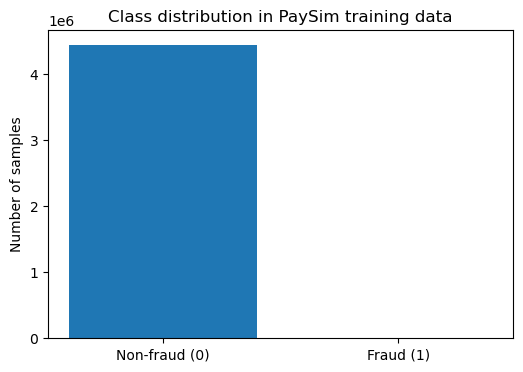

In [39]:
import matplotlib.pyplot as plt

class_counts = y_train.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Non-fraud (0)", "Fraud (1)"], class_counts.values)
plt.title("Class distribution in PaySim training data")
plt.ylabel("Number of samples")
plt.show()

## Comparison bar chart for the 3 methods

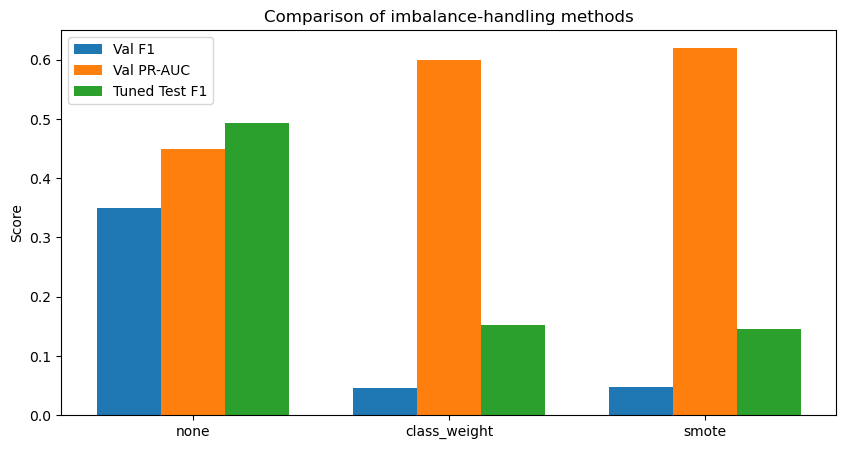

In [40]:
import matplotlib.pyplot as plt
import numpy as np

models = comparison_df["model"]
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, comparison_df["val_f1"], width, label="Val F1")
plt.bar(x, comparison_df["val_pr_auc"], width, label="Val PR-AUC")
plt.bar(x + width, comparison_df["tuned_test_f1"], width, label="Tuned Test F1")

plt.xticks(x, models)
plt.title("Comparison of imbalance-handling methods")
plt.ylabel("Score")
plt.legend()
plt.show()

## Expected cost comparison

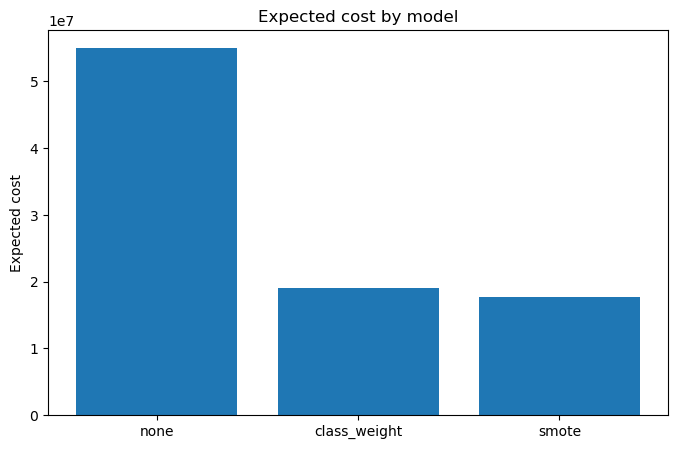

In [41]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["model"], comparison_df["tuned_expected_cost"])
plt.title("Expected cost by model")
plt.ylabel("Expected cost")
plt.show()

## Threshold performance plot

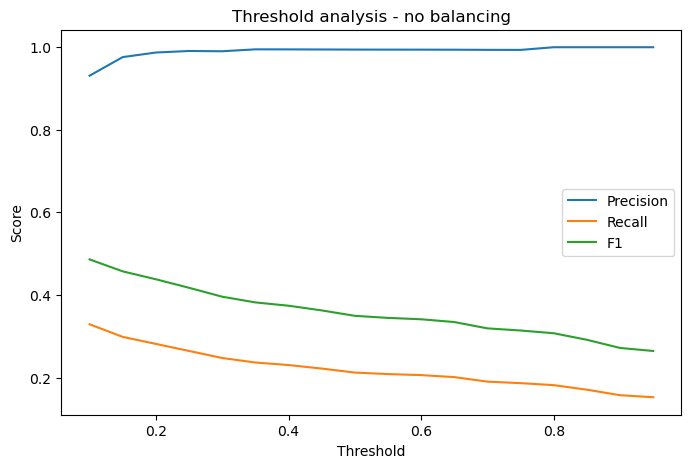

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results_none["threshold"], threshold_results_none["precision"], label="Precision")
plt.plot(threshold_results_none["threshold"], threshold_results_none["recall"], label="Recall")
plt.plot(threshold_results_none["threshold"], threshold_results_none["f1"], label="F1")

plt.title("Threshold analysis - no balancing")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

## Precision-Recall curves

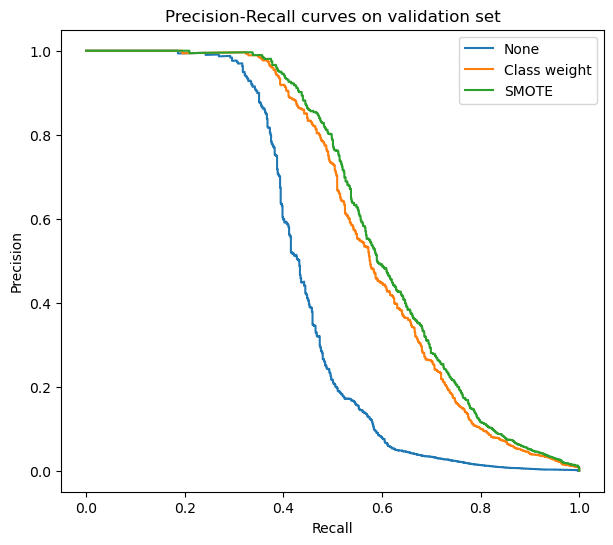

In [44]:
from sklearn.metrics import precision_recall_curve #all three model in one plot

scores_none = model_none.predict_proba(X_val)[:, 1]
scores_weighted = model_weighted.predict_proba(X_val)[:, 1]
scores_smote = model_smote.predict_proba(X_val)[:, 1]

p_none, r_none, _ = precision_recall_curve(y_val, scores_none)
p_weighted, r_weighted, _ = precision_recall_curve(y_val, scores_weighted)
p_smote, r_smote, _ = precision_recall_curve(y_val, scores_smote)

plt.figure(figsize=(7, 6))
plt.plot(r_none, p_none, label="None")
plt.plot(r_weighted, p_weighted, label="Class weight")
plt.plot(r_smote, p_smote, label="SMOTE")

plt.title("Precision-Recall curves on validation set")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

Final choice for full tabular baseline:
- model:
- imbalance handling:
- selected threshold:
- main reason for selection:

Three imbalance-handling strategies were compared for the full PaySim baseline: no balancing, class weighting, and SMOTE. Although the unbalanced model achieved the highest F1-score, it produced the highest expected cost because it missed too many fraudulent cases. Both class weighting and SMOTE substantially improved recall and reduced expected cost. Among them, SMOTE gave the best PR-AUC and the lowest expected cost, and was therefore selected as the final full tabular baseline.

## Final choice

Although the no-balance model had the highest F1-score, it missed too many fraud cases and resulted in the highest expected cost. SMOTE achieved the best overall fraud-focused performance, especially in PR-AUC and expected cost, and was therefore selected as the final full tabular baseline.

In [49]:
final_choice_df = comparison_df.sort_values("tuned_expected_cost").copy()
final_choice_df

,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
2,smote,0.048229,0.993306,0.619049,0.048965,0.994149,0.619863,0.75,0.079611,0.887401,0.146114,17678000
1,class_weight,0.046614,0.991780,0.599905,0.047195,0.992945,0.601748,0.75,0.083687,0.863664,0.152589,18968500
0,none,0.349398,0.946992,0.449465,0.356000,0.952047,0.454219,0.10,0.956140,0.331710,0.492544,54912500


In [62]:
print(comparison_df.to_string(index=False))

       model   val_f1  val_roc_auc  val_pr_auc  test_f1  test_roc_auc  test_pr_auc  best_threshold  tuned_test_precision  tuned_test_recall  tuned_test_f1  tuned_expected_cost
        none 0.349398     0.946992    0.449465 0.356000      0.952047     0.454219            0.10              0.956140           0.331710       0.492544             54912500
class_weight 0.046614     0.991780    0.599905 0.047195      0.992945     0.601748            0.75              0.083687           0.863664       0.152589             18968500
       smote 0.048229     0.993306    0.619049 0.048965      0.994149     0.619863            0.75              0.079611           0.887401       0.146114             17678000


Among the three tested imbalance-handling methods, SMOTE was selected as the final full tabular baseline. Although the model without balancing achieved the highest F1-score, it also produced the highest expected cost because it missed too many fraudulent transactions. Both class weighting and SMOTE improved recall substantially, but SMOTE achieved the best PR-AUC and the lowest expected cost, making it the most suitable choice for the fraud-detection setting.